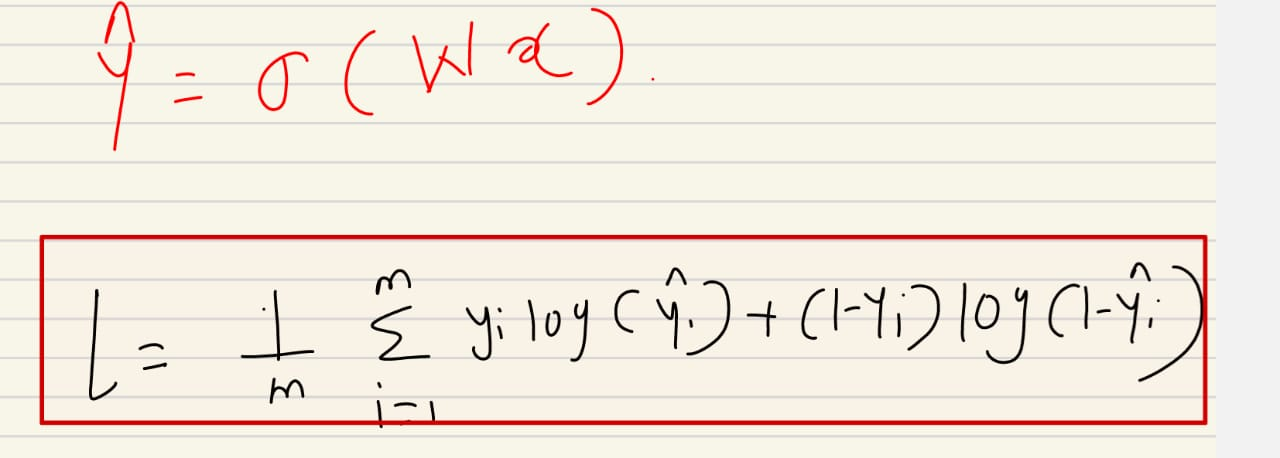

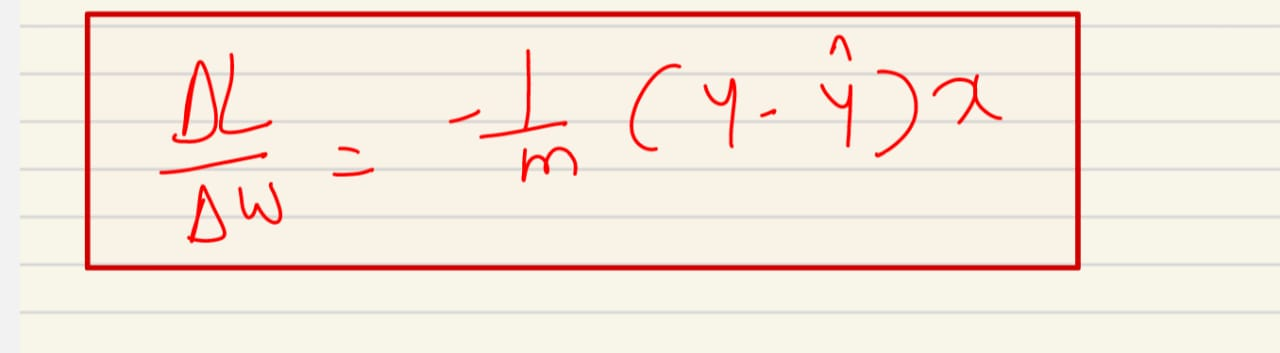

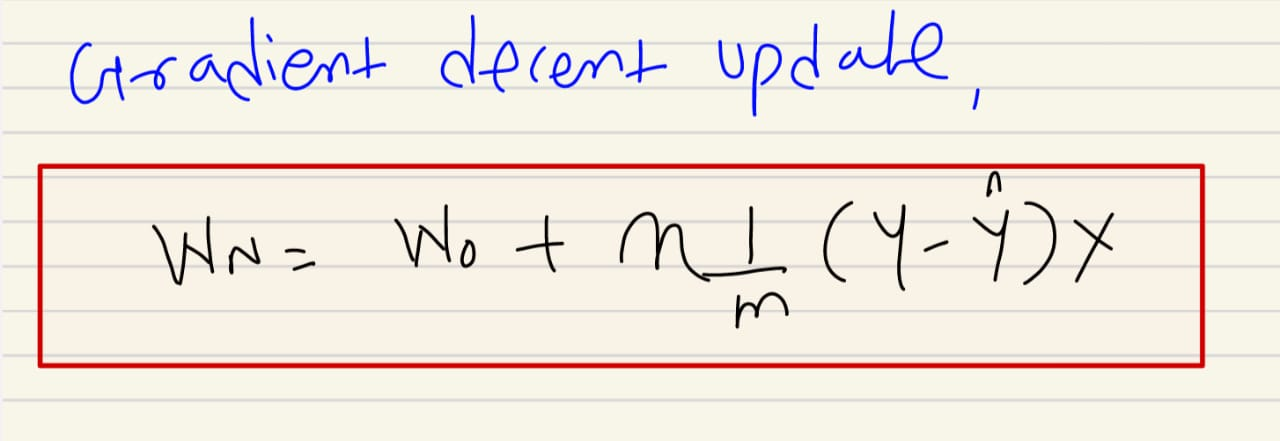

In [5]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

In [2]:
import matplotlib.pyplot as plt

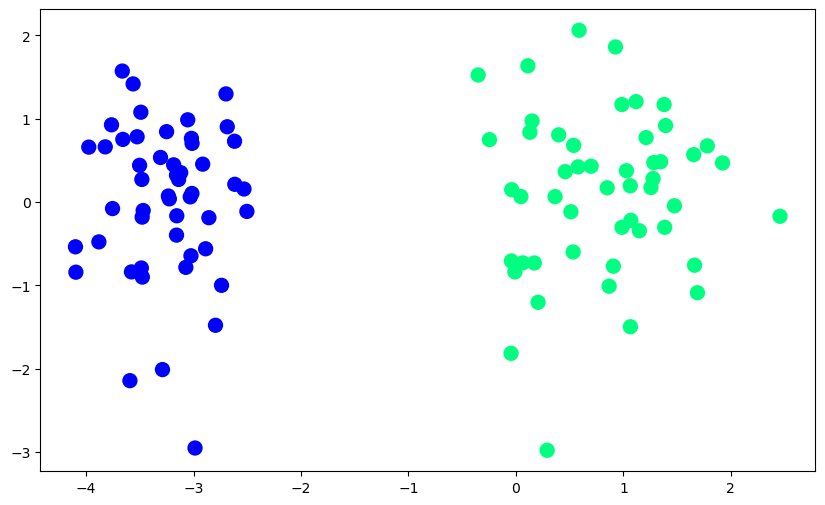

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [7]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(solver='sag')
lor.fit(X,y)

LogisticRegression(solver='sag')

In [8]:
print(lor.coef_)
print(lor.intercept_)

[[2.36760048 0.02167934]]
[3.1393126]


In [9]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

In [10]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

In [11]:
def gd(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5
    
    for i in range(5000):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])
        
    return weights[1:],weights[0]
        

In [12]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [13]:
coef_,intercept_ = gd(X,y)

In [14]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [16]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

(-3.0, 2.0)

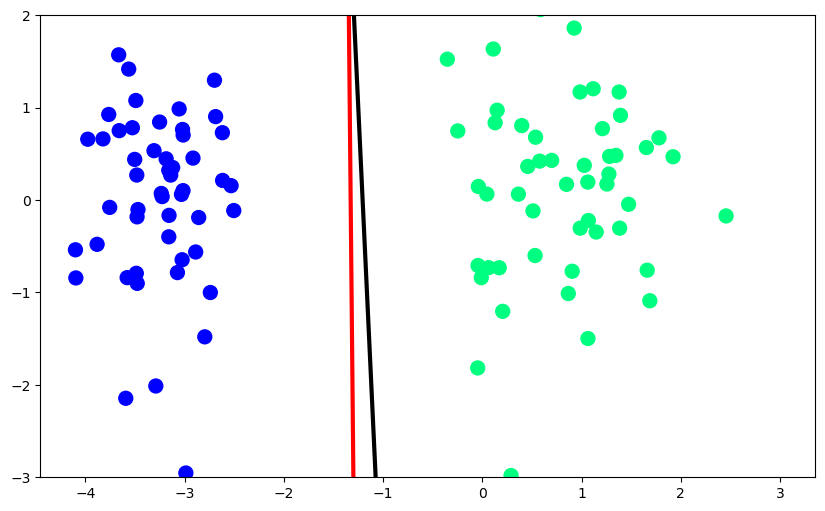

In [17]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

# accuracy score 

 accuracy score is a metric used to evaluate the performance of a classification model. It represents the proportion of correctly classified instances out of the total instances.

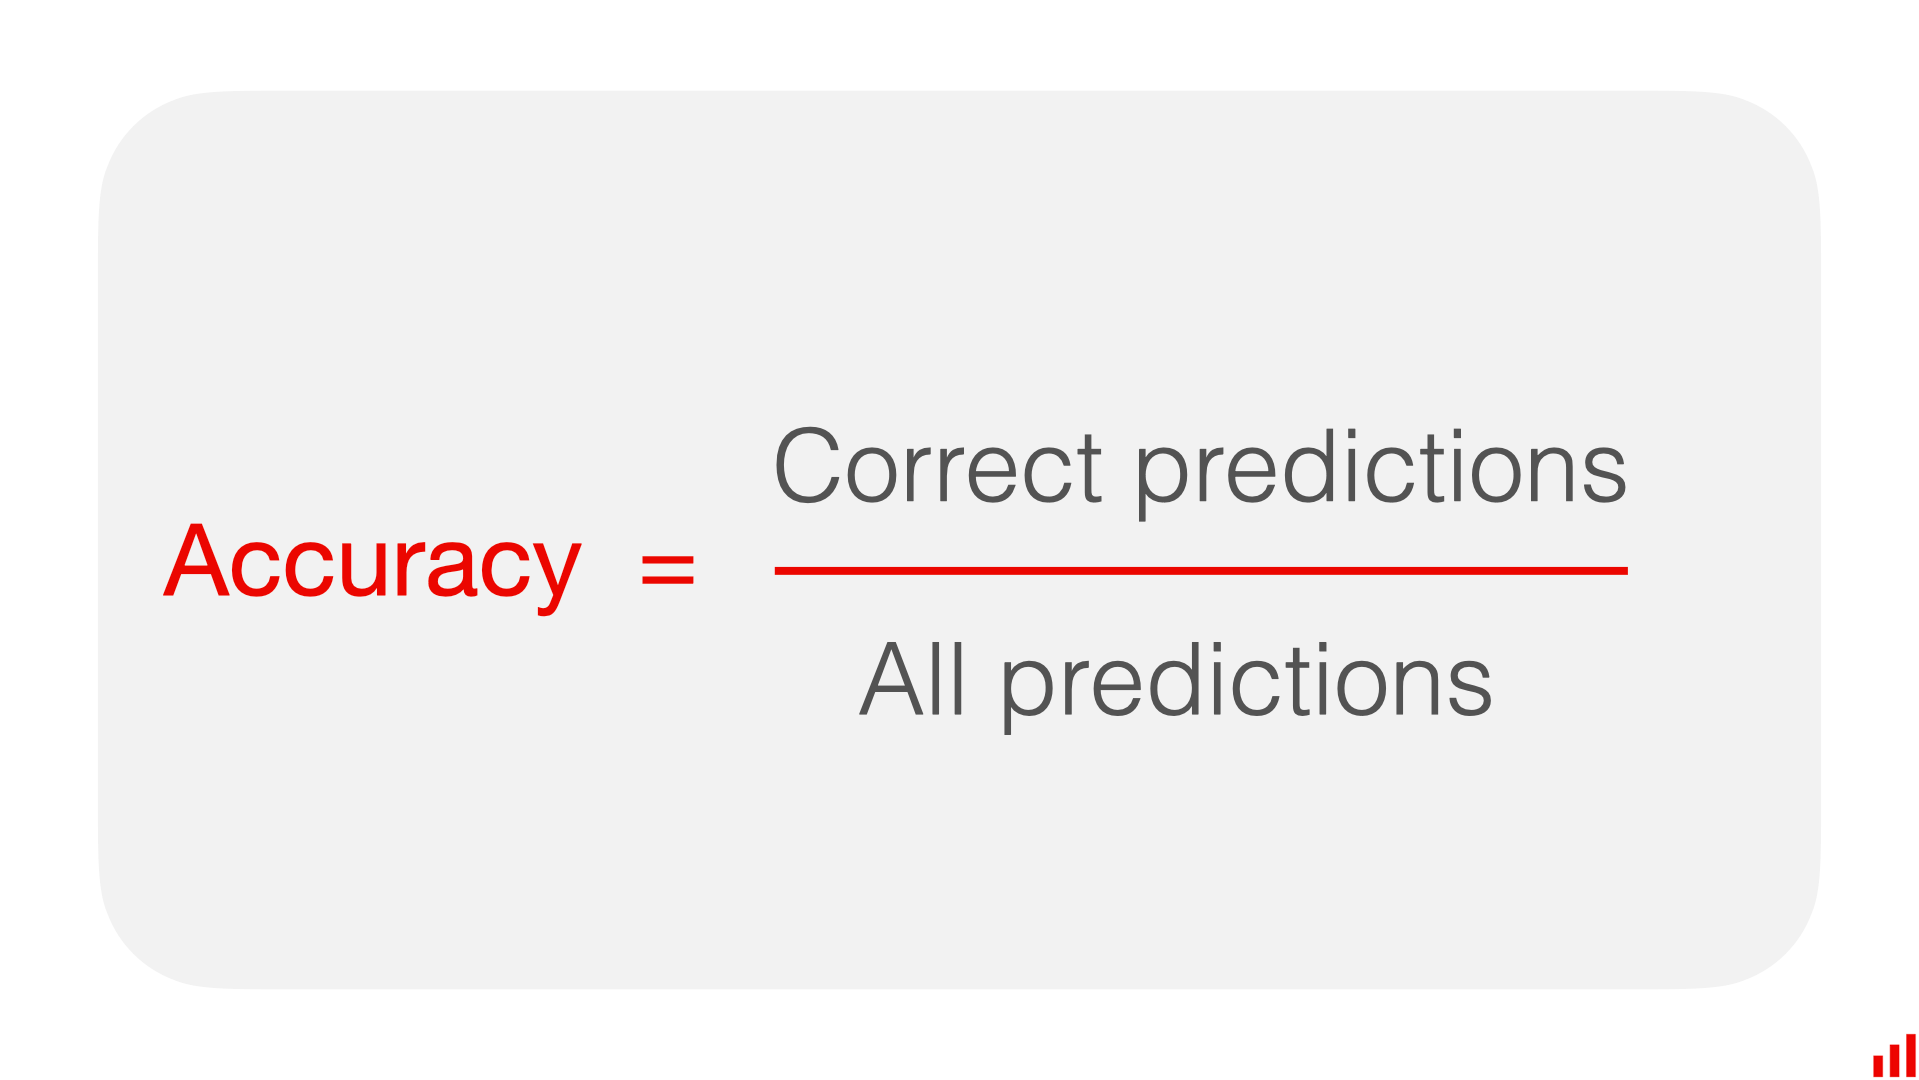

In [18]:
import pandas as pd

In [19]:
df  = pd.read_csv('heart.csv')

df.sample(2)

FileNotFoundError: [Errno 2] No such file or directory: 'heart.csv'

In [12]:
df.shape

(918, 7)

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,0:-1],df.iloc[:,-1],test_size=0.2,random_state=2)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [15]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [16]:

clf1.fit(X_train,y_train)
clf2.fit(X_train,y_train)

DecisionTreeClassifier()

In [17]:

y_pred1 = clf1.predict(X_test)
y_pred2 = clf2.predict(X_test)

In [18]:
print("Will i get Heart Disese : " , clf1.predict([[28,120,130,0,145,2]]))

Will i get Heart Disese :  [1]


C:\Users\Vishal\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [19]:
from sklearn.metrics import accuracy_score,confusion_matrix
print("Accuracy of Logistic Regression",accuracy_score(y_test,y_pred1))
print("Accuracy of Decision Trees",accuracy_score(y_test,y_pred2))

Accuracy of Logistic Regression 0.75
Accuracy of Decision Trees 0.7228260869565217


# How much Accuracy score is Good?

The perception of what constitutes a "good" accuracy score depends heavily on the specific context of the task or problem you're dealing with. In some cases, even a modest accuracy score might be considered excellent, while in other cases, a very high accuracy score might still be insufficient.

# Problem with accuracy score?

Imbalance in the dataset: Accuracy might not be an appropriate metric when dealing with imbalanced datasets, where one class is much more frequent than others. In such cases, a model can achieve high accuracy by simply predicting the majority class all the time, even if it fails to correctly classify instances of the minority class. In these situations, metrics like precision, recall, or F1 score might provide a more balanced view of the model's performance.
    
Misleading performance: Accuracy can sometimes be misleading, especially when the classes are not evenly distributed. For example, in a binary classification problem where 95% of the instances belong to class A and only 5% belong to class B, a model that always predicts class A would achieve 95% accuracy. However, this model would completely fail to detect instances of class B, which might be unacceptable depending on the application.
    
Doesn't account for the cost of errors: In some cases, errors in certain classes might be more costly than in others. For instance, in a medical diagnosis scenario, failing to detect a serious condition might have much graver consequences than incorrectly flagging a healthy person. Accuracy treats all errors equally, which might not reflect the real-world impact of those errors.

Not suitable for regression tasks: Accuracy is typically used for classification tasks where predictions are discrete labels. For regression tasks where predictions are continuous values, metrics like mean absolute error (MAE) or mean squared error (MSE) are more appropriate.
    
Dependence on threshold: In probabilistic classifiers like logistic regression or support vector machines with probabilistic outputs, accuracy can be sensitive to the choice of threshold for class assignment. Different thresholds can lead to different accuracy scores and might not necessarily reflect the model's actual performance.

# confusion matrix

A confusion matrix is a performance measurement tool for machine learning classification algorithms. It's a table that allows visualization of the performance of an algorithm, typically a supervised learning one. It shows the actual performance of the classification model by comparing predicted classes against true classes. The matrix consists of four quadrants:

True Positives (TP): These are the cases where the model correctly predicted the positive class.

True Negatives (TN): These are the cases where the model correctly predicted the negative class.

False Positives (FP): Also known as Type I error, these are the cases where the model incorrectly predicted the positive class when it was actually negative.

False Negatives (FN): Also known as Type II error, these are the cases where the model incorrectly predicted the negative class when it was actually positive.

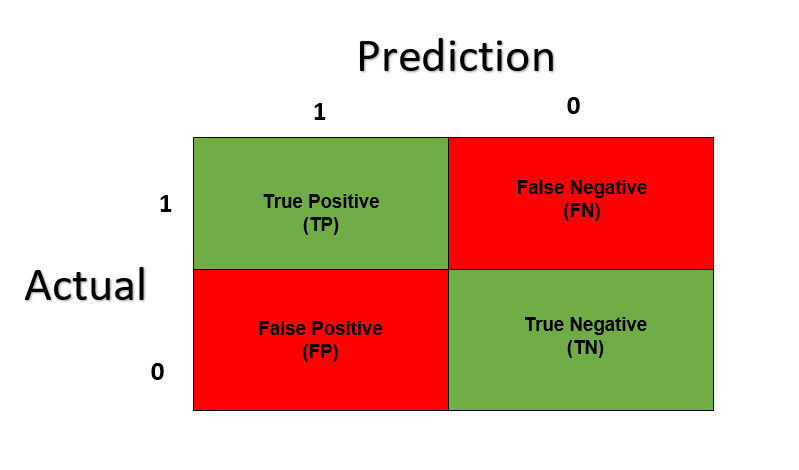

In [20]:
confusion_matrix(y_test,y_pred1)

array([[60, 29],
       [17, 78]], dtype=int64)

In [37]:
import seaborn as sns

<Axes: >

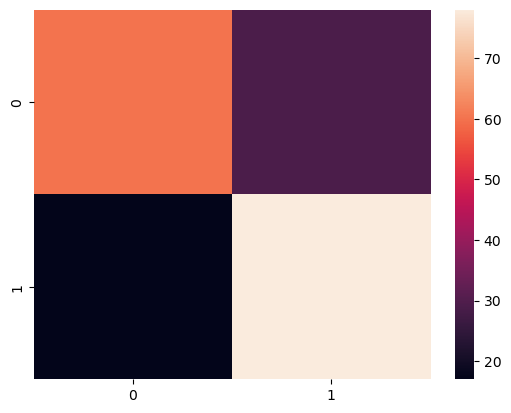

In [38]:
sns.heatmap(confusion_matrix(y_test,y_pred1))